In [1]:
import numpy as np
import pandas as pd
from obspy.core import read, UTCDateTime
from obspy.core.inventory import read_inventory
from obspy.core.util.attribdict import AttribDict
from obspy.clients.fdsn import Client
from collections import defaultdict
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy.taup import TauPyModel
import matplotlib.pyplot as plt

In [2]:
# AUSPASS     https://auspass.edu.au
# BGR         https://eida.bgr.de
# BGS         https://eida.bgs.ac.uk
# EARTHSCOPE  https://service.earthscope.org
# EIDA        http://eida-federator.ethz.ch
# EMSC        https://www.seismicportal.eu
# EPOSFR      https://seisdata.epos-france.fr
# ETH         https://eida.ethz.ch
# GEOFON      https://geofon.gfz.de
# GEONET      https://service.geonet.org.nz
# GFZ         https://geofon.gfz.de
# ICGC        https://ws.icgc.cat
# IESDMC      http://batsws.earth.sinica.edu.tw
# IGN         http://fdsnws.sismologia.ign.es
# INGV        https://webservices.ingv.it
# IPGP        https://ws.ipgp.fr
# IRIS        https://service.earthscope.org
# IRISDMC     https://service.earthscope.org
# IRISPH5     https://service.earthscope.org
# ISC         https://www.isc.ac.uk
# KAGSR       http://sdis.emsd.ru
# KNMI        https://rdsa.knmi.nl
# KOERI       https://eida.koeri.boun.edu.tr
# LMU         https://erde.geophysik.uni-muenchen.de
# NCEDC       https://service.ncedc.org
# NIEP        https://eida-sc3.infp.ro
# NOA         https://eida.gein.noa.gr
# NRCAN       https://earthquakescanada.nrcan.gc.ca
# ODC         https://www.orfeus-eu.org
# ORFEUS      https://www.orfeus-eu.org
# RASPISHAKE  https://data.raspberryshake.org
# RESIF       https://ws.resif.fr
# SCEDC       https://service.scedc.caltech.edu
# TEXNET      http://rtserve.beg.utexas.edu
# UIB-NORSAR  https://eida.geo.uib.no
# USGS        https://earthquake.usgs.gov
# USP         https://sismo.iag.usp.br

In [3]:
def to_number(polarity):
    if polarity == 'positive':
        return 1
    elif polarity == 'negative':
        return -1
    else:
        return 0

In [4]:
# Set Client for Downloading Waveforms
client = Client("SCEDC")
# client = Client("USGS")

In [8]:
# Select Catalog around time of large event in New Zealand
# Start time is P wave arrival time according to Wilber3

starttime = UTCDateTime(1994,2,15,0,0,0)
endtime = UTCDateTime(1994,2,16,0,0,0)
catalog = client.get_events(starttime=starttime, endtime=endtime, minmagnitude=6.0,
                        maxmagnitude=7.0, includearrivals=True)
print(catalog)

FDSNNoDataException: No data available for request.
HTTP Status code: 204
Detailed response of server:



In [62]:
# 6.7 magnitude in the catalog
# get all stations that recorded the event
event0, event1 = catalog
event1

Event:	1994-01-17T12:30:55.390000Z | +34.213, -118.537 | 6.7  Mw | manual

	            resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?eventid=3144585")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='CI', agency_uri=ResourceIdentifier(id="quakeml:doi.org/10.7909/C3WD3xH1"), creation_time=UTCDateTime(2002, 8, 28, 7, 22, 19), version='1')
	    preferred_origin_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?originid=1773151")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?magnitudeid=2694547")
	                   ---------
	               comments: 1 Elements
	                  picks: 194 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements

In [63]:
[pick for pick in event1.picks if pick.phase_hint == 'P' and pick.waveform_id.station_code == 'LA02']

[Pick
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?assocaro=30684975")
	              time: UTCDateTime(1994, 1, 17, 12, 30, 57, 740000) [uncertainty=0.03]
	       waveform_id: WaveformStreamID(network_code='ZY', station_code='LA02', channel_code='EHZ', location_code='')
	             onset: 'impulsive'
	        phase_hint: 'P'
	          polarity: 'undecidable'
	   evaluation_mode: 'manual'
	 evaluation_status: 'final'
	     creation_info: CreationInfo(agency_id='CI', creation_time=UTCDateTime(2002, 7, 1, 21, 33, 42)),
 Pick
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?assocaro=30684983")
	              time: UTCDateTime(1994, 1, 17, 12, 30, 57, 740000) [uncertainty=0.03]
	       waveform_id: WaveformStreamID(network_code='ZY', station_code='LA02', channel_code='EHZ', location_code='')
	             onset: 'impulsive'
	        phase_hint: 'P'
	          polarity: 'undecidable'
	

In [64]:
[(pick.waveform_id.station_code, pick.waveform_id.channel_code, pick.polarity) for pick in event1.picks
  if pick.waveform_id.channel_code[0] != 'B' and pick.waveform_id.station_code == 'SMF']

[('SMF', 'EHZ', 'negative')]

In [ ]:
# plot seismogram of station

# check for what stations in example are in SCEDC
# the goal is to use overlapping stations from SKHASH

# translate data format from HASH to csv (SKHASH)

# can we use SKHASH correctly? We have to use the same stations

# find something that works from scratch...

In [65]:
# what's the thing called... get coordinates of station

# get station coordinates
inventory = client.get_stations(network="CI", station="ABL", level="channel")
print(inventory)
# dir(inventory[0])
inventory.get_coordinates('CI.ABL..VEI')


Inventory created at 2026-05-15T20:28:12.000000Z
	Created by: SCEDC WEB SERVICE: fdsnws-station | version: 1.1
		    http://service.scedc.caltech.edu/fdsnws/station/1/query?net=CI&sta=...
	Sending institution: SCEDC (SCEDC)
	Contains:
		Networks (1):
			CI
		Stations (2):
			CI.ABL (Mount Abel) (2x)
		Channels (146):
			CI.ABL..ABT (2x), CI.ABL..ACE (2x), CI.ABL..ACA (2x), 
			CI.ABL..ACF (2x), CI.ABL..ACK (2x), CI.ABL..ACQ (2x), 
			CI.ABL..ACS (2x), CI.ABL..ADG (2x), CI.ABL..ADL (2x), 
			CI.ABL..ADT (2x), CI.ABL..ALL (2x), CI.ABL..AMD (2x), 
			CI.ABL..ANI (2x), CI.ABL..APK (2x), CI.ABL..APO (2x), 
			CI.ABL..ARD (2x), CI.ABL..ASL (2x), CI.ABL..ASQ (2x), 
			CI.ABL..ATH (2x), CI.ABL..AWR (2x), CI.ABL..BHZ (2x), 
			CI.ABL..BHN (2x), CI.ABL..BHE (2x), CI.ABL..EHZ (4x), 
			CI.ABL..HHZ (2x), CI.ABL..HHN (2x), CI.ABL..HHE (2x), 
			CI.ABL..HNZ (2x), CI.ABL..HNN (2x), CI.ABL..HNE (2x), 
			CI.ABL..LAT (2x), CI.ABL..LCE (2x), CI.ABL..LCL (2x), 
			CI.ABL..LCQ (2x), CI.ABL..LEA (2x), CI.A

/home/vay3059/.local/lib/python3.12/site-packages/obspy/core/inventory/network.py:321: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)


{'latitude': 34.84843,
 'longitude': -119.224965,
 'elevation': 1975.0,
 'local_depth': 0.0}

In [66]:
mydict = inventory.get_coordinates('CI.ABL..LHZ')
mydict
# list(mydict.values())[:2]

{'latitude': 34.84843,
 'longitude': -119.224965,
 'elevation': 1974.2,
 'local_depth': 0.8}

In [67]:
# WR.PYR..EHZ
inventory = client.get_stations(network="WR", station="PYR", level="channel")
inventory.get_coordinates('WR.PYR..EHZ')

/home/vay3059/.local/lib/python3.12/site-packages/obspy/core/inventory/network.py:321: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)


{'latitude': 34.567799,
 'longitude': -118.741898,
 'elevation': 1245.0,
 'local_depth': 0.0}

In [68]:
# create a dictionary that stores sign for each station
data_dict = defaultdict(list)

for idx, pick in enumerate(event1.picks):
    if idx % 10 == 0:
        print(f"Processing pick {idx}/{len(event1.picks)}")
    if pick.phase_hint == 'P':
        stat = pick.waveform_id.station_code
        net = pick.waveform_id.network_code
        chan = pick.waveform_id.channel_code
        loc = pick.waveform_id.location_code
        seed_id = '.'.join([net, stat, loc, chan])
        try:
            inventory = client.get_stations(starttime=pick.time, endtime=pick.time + 1,
                                            network=net, station=stat, channel=chan, level="channel")
        except Exception as e:
            print(f"Error occurred while fetching station information for {seed_id}")
            # print error message
            print(f"Error: {e}")
            continue
        
        try:
            coordinates = inventory.get_coordinates(seed_id)
        except Exception as e:
            print(f"Error occurred while fetching coordinates for {seed_id}")
            # print error message
            print(f"Error: {e}")
            continue
        
        if len(data_dict[seed_id]) == 0:
            data_dict[seed_id].extend(list(coordinates.values())[:2] + [to_number(pick.polarity)])
        
        

# collapse to sign
for seed_id in data_dict:
    if abs(data_dict[seed_id][2]) > 1: print(f"{seed_id} has polarity {data_dict[seed_id][2]}")
    data_dict[seed_id][2] = np.sign(data_dict[seed_id][2])

Processing pick 0/194
Processing pick 10/194
Processing pick 20/194
Error occurred while fetching station information for AZ.PFO..BHE
Error: No data available for request.
HTTP Status code: 204
Detailed response of server:


Processing pick 30/194
Processing pick 40/194
Error occurred while fetching coordinates for WR.PYR..EHZ
Error: No matching channel metadata found.
Processing pick 50/194
Processing pick 60/194
Processing pick 70/194
Processing pick 80/194
Processing pick 90/194
Processing pick 100/194
Processing pick 110/194
Error occurred while fetching station information for LA.SC1..EHZ
Error: No data available for request.
HTTP Status code: 204
Detailed response of server:


Processing pick 120/194
Error occurred while fetching station information for LA.TPR..EHZ
Error: No data available for request.
HTTP Status code: 204
Detailed response of server:


Error occurred while fetching station information for BK.PRI..EHZ
Error: No data available for request.
HTTP Status code: 204
D

In [ ]:
# NOTE: get event location
lat = event1.origins[0].latitude
lon = event1.origins[0].longitude
hdepth = event1.origins[0].depth/1000 # convert to km

col_string = 'event_id, station, network, location, channel, p_polarity, takeoff, takeoff_uncertainty, azimuth, azimuth_uncertainty'
columns = [col.strip() for col in col_string.split(',')]
df = pd.DataFrame(columns=columns)
event_id = 1
takeoff_unc = 0.1 # placeholder
az_unc = 0.1 # placeholder
epdists = []

velocity_model = TauPyModel(model='ak135')
# velocity_model = TauPyModel(model='iasp91')

for key, value in data_dict.items():
    net, stat, loc, chan = key.split('.')
    p_polarity = value[2]
    src2dst = [lat, lon, value[0], value[1]]
    dist, az, baz = gps2dist_azimuth(*src2dst)
    epdist = kilometers2degrees(dist / 1000) # convert to km
    
    try:
        print()
        print(f"INPUTS:\n{hdepth} km depth, {epdist:.2f} degrees distance")
        p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                            distance_in_degree=epdist, phase_list=['P'])
                            # phase_list=['P', 'Pn', 'Pg'])
        print(f"OUTPUTS:")
        for arrival in p_arrivals:
            print(f"Phase: {arrival.phase.name}, Time: {arrival.time:.2f} s, Takeoff angle: {arrival.takeoff_angle:.2f} degrees")
        print()
    except Exception as e:
        print(f"Error occurred while calculating travel times for station {stat}")
        # print error message
        print(f"Error: {e}")
        continue
    
    if len(p_arrivals) == 0:
        print(f"Station {stat} has no P arrival. Skipping.")
        print(f"Epidist = {epdist:.2f} degrees, depth = {hdepth} km")
        continue
    
    epdists.append(epdist)
    takeoff = p_arrivals[0].takeoff_angle
    takeoff = 180 - takeoff # convert to angle from vertical (SKHASH convention)
    
    if p_polarity != 0:
        df.loc[len(df)] = [event_id, stat, net, loc, chan, float(p_polarity),
                        takeoff, takeoff_unc, az, az_unc]
    else: print(f"Station {stat} has zero polarity. Skipping.")


INPUTS:
18.202 km depth, 0.13 degrees distance
OUTPUTS:

Station LA00 has no P arrival. Skipping.
Epidist = 0.13 degrees, depth = 18.202 km

INPUTS:
18.202 km depth, 0.13 degrees distance
OUTPUTS:

Station LA00 has no P arrival. Skipping.
Epidist = 0.13 degrees, depth = 18.202 km

INPUTS:
18.202 km depth, 0.18 degrees distance
OUTPUTS:

Station LA02 has no P arrival. Skipping.
Epidist = 0.18 degrees, depth = 18.202 km

INPUTS:
18.202 km depth, 0.35 degrees distance
OUTPUTS:

Station LA04 has no P arrival. Skipping.
Epidist = 0.35 degrees, depth = 18.202 km

INPUTS:
18.202 km depth, 0.31 degrees distance
OUTPUTS:

Station PAS has no P arrival. Skipping.
Epidist = 0.31 degrees, depth = 18.202 km

INPUTS:
18.202 km depth, 0.28 degrees distance
OUTPUTS:

Station USC has no P arrival. Skipping.
Epidist = 0.28 degrees, depth = 18.202 km

INPUTS:
18.202 km depth, 2.18 degrees distance
OUTPUTS:
Phase: P, Time: 35.37 s, Takeoff angle: 46.01 degrees
Phase: Pn, Time: 35.37 s, Takeoff angle: 46.0

In [70]:
epdist = epdists[10]
p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                            distance_in_degree=epdist, phase_list=['P', 'Pn', 'Pg'])

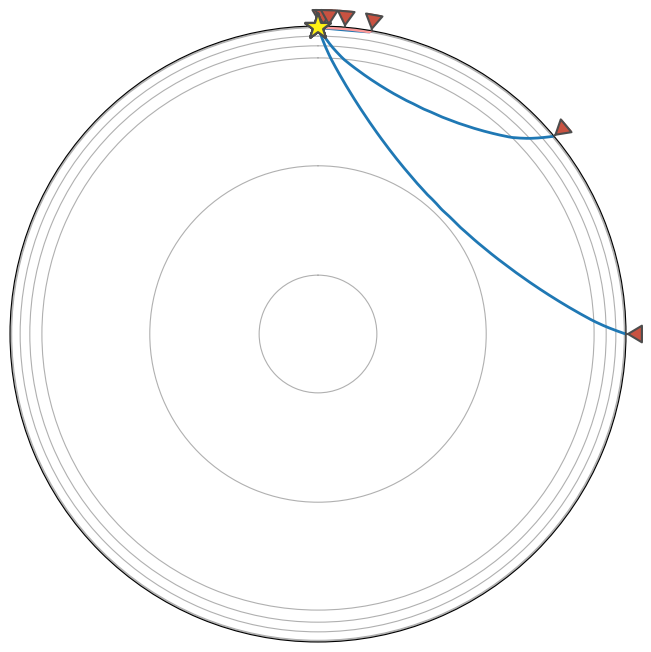

In [71]:
from obspy.taup import TauPyModel
import matplotlib.pyplot as plt

model = TauPyModel(model="ak135")

depth_km = 18.2
distances = [0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 90.0]


fig, ax = plt.subplots(
    subplot_kw=dict(polar=True),
    figsize=(8, 8)
)

for dist in distances:
    arrivals = model.get_ray_paths(
        source_depth_in_km=depth_km,
        distance_in_degree=dist,
        phase_list=["P", "Pg", "Pn"]
    )

    arrivals.plot_rays(
        fig=fig,
        ax=ax,
        show=False
    )

plt.show()

In [72]:
hdepth

18.202

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


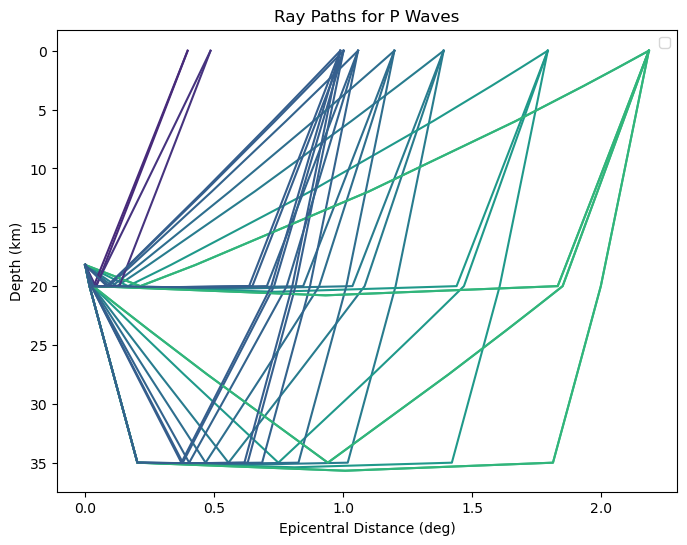

In [82]:
model = TauPyModel(model="ak135")

fig, ax = plt.subplots(figsize=(8, 6))

max_count = 10
min_count = 0
count = 0

for epdist in epdists:
    
    arrivals = model.get_ray_paths(
        source_depth_in_km=hdepth,
        distance_in_degree=epdist,
        phase_list=["P"]
    )

    for arr in arrivals:

        path = arr.path # check it out

        x = np.degrees(path["dist"])
        y = path["depth"]

        # same but with color bar
        color = plt.cm.viridis(epdist / max(epdists))
        ax.plot(x, y, color=color)
    
    count += 1
    if count >= max_count: break
        

ax.invert_yaxis()
ax.set_xlabel("Epicentral Distance (deg)")
ax.set_ylabel("Depth (km)")
ax.legend()

plt.title("Ray Paths for P Waves")

plt.show()


In [74]:
dir(p_arrivals[0])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'distance',
 'incident_angle',
 'name',
 'path',
 'phase',
 'pierce',
 'purist_dist',
 'purist_distance',
 'purist_name',
 'ray_param',
 'ray_param_index',
 'ray_param_sec_degree',
 'receiver_depth',
 'source_depth',
 'takeoff_angle',
 'time']

In [75]:
# NOTE: ask for a ray path diagram (TauPy function)
# NOTE: sensitivity analysis for velocity model picking

In [76]:
# dir(velocity_model)
dir(velocity_model.model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_depth_cache',
 '_load_from_depth_cache',
 'calc_tau_inc_from',
 'cmb_branch',
 'cmb_depth',
 'debug',
 'depth_correct',
 'deserialize',
 'find_branch',
 'from_file',
 'get_branch_depths',
 'get_tau_branch',
 'iocb_branch',
 'iocb_depth',
 'is_spherical',
 'load_from_depth_cache',
 'moho_branch',
 'moho_depth',
 'no_discon_depths',
 'radius_of_planet',
 'ray_params',
 's_mod',
 'serialize',
 'source_branch',
 'source_depth',
 'split_branch',
 'tau_branches',
 'validate']

In [77]:
df

,event_id,station,network,location,channel,p_polarity,takeoff,takeoff_uncertainty,azimuth,azimuth_uncertainty
0,1,BAR,CI,,BHE,1.0,133.993962,0.1,133.920430,0.1
1,1,DGR,CI,,BHE,-1.0,133.992913,0.1,113.425264,0.1
2,1,GSC,CI,,BHE,-1.0,133.995356,0.1,52.201480,0.1
3,1,SBC,CI,,BHE,-1.0,116.873144,0.1,283.451126,0.1
4,1,SVD,CI,,BHE,1.0,133.991757,0.1,94.685583,0.1
...,...,...,...,...,...,...,...,...,...,...
124,1,PTQ,NC,,EHZ,1.0,133.994944,0.1,282.897540,0.1
125,1,PMG,NC,,EHZ,-1.0,133.993052,0.1,307.214136,0.1
126,1,WIN,CI,,EHZ,1.0,133.992397,0.1,113.525249,0.1
127,1,BAC,CI,,EHZ,1.0,133.992868,0.1,115.294783,0.1


In [78]:
# save to csv
df.to_csv('event1_data.csv', index=False)